# Frobenius Group of Order 21: Spherical Training with Unshared Embedding

This notebook demonstrates Stage 1 training on the **Frobenius group G = C_7 ⋊ C_3** with **unshared embedding** (`share_embed=False`).

**Task**: Group multiplication (g, h) → g·h (non-commutative)

**Group**: G = C_7 ⋊ C_3 (unique non-abelian group of order 21)
- Elements: pairs (a, b) where a ∈ {1, 2, 4} ⊂ Z_7* and b ∈ Z_7
- Multiplication: (a, b) · (a', b') = (a·a' mod 7, b + a·b' mod 7)

**Basis**: 5 irreducible representations:
- trivial (1D): ρ(g) = 1
- omega (1D): ρ(a,b) = ω^k where a = 2^k, ω = e^(2πi/3)
- omega_conj (1D): conjugate of omega
- rho_3 (3D): constructed from generators
- rho_3_conj (3D): complex conjugate of rho_3

**Key feature**: Both 1D (omega/omega_conj) and 3D (rho_3/rho_3_conj) irreps form **non-self-conjugate pairs**.

In [86]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from src.tasks import Frobenius21Multiplication
from src.basis import Frobenius21Basis
from src.model import WideNetworkScaleSphere
from src.utils import (
    cross_entropy_high_precision,
    accuracy,
    project_gradient_to_tangent_space,
    normalize_to_pi,
)

# Font settings - use Palatino, no LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'P052', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# Custom colormap: blue -> white -> red
blue_white_red = LinearSegmentedColormap.from_list(
    'blue_white_red',
    ['#0D2758', 'white', '#A32015'],
    N=256
)

## 1. Configuration

In [87]:
# === Frobenius Group Configuration ===
# |G| = 21 (7 * 3)

# Model
WIDTH = 128
ACT_TYPE = 'Quad'
INIT_SCALE = 0.5
SHARE_EMBED = False  # Unshared for non-commutative operation

# Training
LR = 1e-1
NUM_EPOCHS = 30000
PRINT_EVERY = 500

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cpu')

vocab_size = 21
print(f"Frobenius Group: G = C_7 ⋊ C_3")
print(f"Group size: |G| = 21")
print(f"Dataset size: {vocab_size}² = {vocab_size**2} pairs")
print(f"Model: width={WIDTH}, activation={ACT_TYPE}, share_embed={SHARE_EMBED}")

Frobenius Group: G = C_7 ⋊ C_3
Group size: |G| = 21
Dataset size: 21² = 441 pairs
Model: width=128, activation=Quad, share_embed=False


## 2. Initialize Task, Basis, and Model

In [88]:
# Create task and basis
task = Frobenius21Multiplication()
basis = Frobenius21Basis()

print(f"Task: {task}")
print(f"Basis: {basis}")
print(f"\nIrreducible representations (label -> dimension):")
for label, dim in basis.irrep_dimensions.items():
    print(f"  {label}: dim = {dim} -> contributes {dim**2} basis functions")
print(f"\nTotal basis functions: {sum(d**2 for d in basis.irrep_dimensions.values())} = {vocab_size}")
print(f"\nConjugate pairs:")
print(f"  - omega & omega_conj (both 1D)")
print(f"  - rho_3 & rho_3_conj (both 3D)")

Task: Frobenius21Multiplication(vocab_size=21)
Basis: Frobenius21Basis(size=21, irreps={trivial:1, omega:1, omega_conj:1, rho_3:3, rho_3_conj:3})

Irreducible representations (label -> dimension):
  trivial: dim = 1 -> contributes 1 basis functions
  omega: dim = 1 -> contributes 1 basis functions
  omega_conj: dim = 1 -> contributes 1 basis functions
  rho_3: dim = 3 -> contributes 9 basis functions
  rho_3_conj: dim = 3 -> contributes 9 basis functions

Total basis functions: 21 = 21

Conjugate pairs:
  - omega & omega_conj (both 1D)
  - rho_3 & rho_3_conj (both 3D)


In [89]:
# Generate data
data, labels = task.generate_all_data(device)

# Create model
model = WideNetworkScaleSphere(
    d_vocab=vocab_size,
    width=WIDTH,
    act_type=ACT_TYPE,
    init_scale=INIT_SCALE,
    share_embed=SHARE_EMBED,
).to(device)

print(f"\nModel architecture:")
print(f"  W_in:  {model.W_in.shape}  <- (width, 2*vocab_size) for unshared")
print(f"  W_out: {model.W_out.shape}")
print(f"  scale_in:  {model.scale_in.item():.4f}")
print(f"  scale_out: {model.scale_out.item():.4f}")
print(f"\nDataset: {len(data)} samples")


Model architecture:
  W_in:  torch.Size([128, 42])  <- (width, 2*vocab_size) for unshared
  W_out: torch.Size([21, 128])
  scale_in:  0.5000
  scale_out: 0.5000

Dataset: 441 samples


## 3. Run Stage 1 Training (Projected GD on Sphere)

In [90]:
# Save initial weights before training
W_in_init = model.W_in.detach().cpu().clone()
W_out_init = model.W_out.detach().cpu().clone()

# Freeze scales
model.scale_in.requires_grad = False
model.scale_out.requires_grad = False

# Optimizer for directions only
#optimizer = optim.Adam([model.W_in, model.W_out], lr=LR)
#LR = 1; optimizer = optim.SGD([model.W_in, model.W_out], lr=LR); NUM_EPOCHS = 15000
optimizer = optim.SGD([model.W_in, model.W_out], lr=LR)

# Training history
losses = []
accuracies = []

# --- Alignment metric tracking during training ---
def d_sim_training(C1, C2):
    """Compute similarity metric between two matrices."""
    vec1 = C1.flatten()
    vec2 = C2.flatten()
    inner = np.abs(np.vdot(vec1, vec2))
    norm1 = np.linalg.norm(C1, 'fro')
    norm2 = np.linalg.norm(C2, 'fro')
    if norm1 < 1e-10 or norm2 < 1e-10:
        return 0.0
    return inner / (norm1 * norm2)

def extract_irrep_matrices_training(dft_coeffs, irrep_labels, irrep_dims):
    """Extract per-irrep matrices from DFT coefficients."""
    n_neurons = dft_coeffs.shape[0]
    irrep_matrices = {}
    curr_idx = 0
    for label in irrep_labels:
        d = irrep_dims[label]
        block = dft_coeffs[:, curr_idx:curr_idx + d*d]
        irrep_matrices[label] = block.reshape(n_neurons, d, d)
        curr_idx += d * d
    return irrep_matrices

def compute_irrep_energy_training(dft_mag, irrep_labels, irrep_dims):
    """Compute L²(G) energy d_ρ ||ν̂[ρ]||²_F for each neuron."""
    n_neurons = dft_mag.shape[0]
    energy = np.zeros((n_neurons, len(irrep_labels)))
    idx = 0
    for i, label in enumerate(irrep_labels):
        d = irrep_dims[label]
        energy[:, i] = d * np.sum(dft_mag[:, idx:idx + d*d] ** 2, axis=1)
        idx += d * d
    return energy

def compute_grouped_energy_training(energy, irrep_labels):
    """Combine energy for conjugate irrep pairs."""
    # Frobenius21 conjugate pairs
    CONJUGATE_PAIRS = {
        'omega': 'omega_conj', 'omega_conj': 'omega',
        'rho_3': 'rho_3_conj', 'rho_3_conj': 'rho_3',
    }
    n_neurons = energy.shape[0]
    grouped_labels = []
    seen = set()
    for label in irrep_labels:
        if label in seen:
            continue
        if label in CONJUGATE_PAIRS:
            conj = CONJUGATE_PAIRS[label]
            grouped_labels.append(f"{label}+{conj}")
            seen.add(label)
            seen.add(conj)
        else:
            grouped_labels.append(label)
            seen.add(label)
    
    grouped_energy = np.zeros((n_neurons, len(grouped_labels)))
    for gi, glabel in enumerate(grouped_labels):
        if '+' in glabel:
            parts = glabel.split('+')
            for part in parts:
                idx = irrep_labels.index(part)
                grouped_energy[:, gi] += energy[:, idx]
        else:
            idx = irrep_labels.index(glabel)
            grouped_energy[:, gi] = energy[:, idx]
    
    return grouped_energy, grouped_labels

def compute_sv_ratio(mat):
    """Compute σ₂/σ₁ ratio for rank-1 check. Returns 0 if matrix is essentially zero or 1D."""
    if mat.shape[0] == 1 or mat.shape[1] == 1:
        return 0.0  # 1D irreps are trivially rank-1
    sv = np.linalg.svd(mat, compute_uv=False)
    if sv[0] < 1e-10:
        return 0.0
    return sv[1] / sv[0] if len(sv) > 1 else 0.0

def compute_all_metrics_at_epoch(model_obj, basis_obj, vocab_sz):
    """Compute alignment, energy, and rank-1 metrics for ALL irreps."""
    W_in = model_obj.W_in.detach().cpu()
    W_out = model_obj.W_out.detach().cpu()
    
    W_in_pos1 = W_in[:, :vocab_sz]
    W_in_pos2 = W_in[:, vocab_sz:]
    
    # Normalize
    W_in_pos1_norm = W_in_pos1 / W_in_pos1.norm(dim=1, keepdim=True)
    W_in_pos2_norm = W_in_pos2 / W_in_pos2.norm(dim=1, keepdim=True)
    W_out_norm = W_out / W_out.norm(dim=0, keepdim=True)
    
    # Apply Fourier transform
    W_in_pos1_dft = basis_obj.transform_paper(W_in_pos1_norm).numpy()
    W_in_pos2_dft = basis_obj.transform_paper(W_in_pos2_norm).numpy()
    W_out_dft = basis_obj.transform_paper(W_out_norm.T).numpy()
    
    # Extract matrices
    W1_mats = extract_irrep_matrices_training(W_in_pos1_dft, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    W2_mats = extract_irrep_matrices_training(W_in_pos2_dft, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    Wout_mats = extract_irrep_matrices_training(W_out_dft, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    
    # Compute energy for each parameter separately (θ₁, θ₂, ξ)
    mag_theta1 = np.abs(W_in_pos1_dft)
    mag_theta2 = np.abs(W_in_pos2_dft)
    mag_xi = np.abs(W_out_dft)
    
    energy_theta1 = compute_irrep_energy_training(mag_theta1, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    energy_theta2 = compute_irrep_energy_training(mag_theta2, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    energy_xi = compute_irrep_energy_training(mag_xi, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    
    grouped_energy_theta1, grouped_labels = compute_grouped_energy_training(energy_theta1, basis_obj.irrep_labels)
    grouped_energy_theta2, _ = compute_grouped_energy_training(energy_theta2, basis_obj.irrep_labels)
    grouped_energy_xi, _ = compute_grouped_energy_training(energy_xi, basis_obj.irrep_labels)
    
    n_neurons = W_in.shape[0]
    
    # Alignment metrics for ALL irreps
    alignment_metrics = {label: {'cond1': [], 'cond2': [], 'cond3': []} 
                         for label in basis_obj.irrep_labels if label != 'trivial'}
    
    # Rank-1 metrics (σ₂/σ₁) for ALL irreps
    rank1_metrics = {label: {'theta1': [], 'theta2': [], 'xi': []} 
                     for label in basis_obj.irrep_labels if basis_obj.irrep_dimensions[label] > 1}
    
    for m in range(n_neurons):
        for irrep_label in basis_obj.irrep_labels:
            if irrep_label == 'trivial':
                continue
            
            W1 = W1_mats[irrep_label][m]
            W2 = W2_mats[irrep_label][m]
            Wout = Wout_mats[irrep_label][m]
            
            # Alignment
            alignment_metrics[irrep_label]['cond1'].append(d_sim_training(W2 @ W1, Wout))
            alignment_metrics[irrep_label]['cond2'].append(d_sim_training(W2.conj().T @ Wout, W1))
            alignment_metrics[irrep_label]['cond3'].append(d_sim_training(Wout @ W1.conj().T, W2))
            
            # Rank-1 (only for d > 1 irreps)
            d = basis_obj.irrep_dimensions[irrep_label]
            if d > 1:
                rank1_metrics[irrep_label]['theta1'].append(compute_sv_ratio(W1))
                rank1_metrics[irrep_label]['theta2'].append(compute_sv_ratio(W2))
                rank1_metrics[irrep_label]['xi'].append(compute_sv_ratio(Wout))
    
    return alignment_metrics, grouped_energy_theta1, grouped_energy_theta2, grouped_energy_xi, grouped_labels, rank1_metrics

# Storage for metrics over time
TRACK_EVERY = 10
epochs_tracked = []

# Alignment: {irrep_label: {cond1: [list per epoch], ...}}
alignment_history_all = {label: {'cond1': [], 'cond2': [], 'cond3': []} 
                         for label in basis.irrep_labels if label != 'trivial'}

# Energy: separate histories for θ₁, θ₂, ξ
grouped_energy_history_theta1 = []
grouped_energy_history_theta2 = []
grouped_energy_history_xi = []
grouped_labels_cache = None

# Rank-1: {irrep_label: {theta1: [list per epoch], theta2: [...], xi: [...]}}
rank1_history = {label: {'theta1': [], 'theta2': [], 'xi': []} 
                 for label in basis.irrep_labels if basis.irrep_dimensions[label] > 1}

print("=" * 60)
print("Stage 1: Projected GD (Directions only, Scale fixed)")
print("=" * 60)
print(f"Fixed scale_in = {model.scale_in.item():.4f}, scale_out = {model.scale_out.item():.4f}")

for epoch in range(NUM_EPOCHS):
    # Track metrics at intervals
    if epoch % TRACK_EVERY == 0:
        align_m, ge_theta1, ge_theta2, ge_xi, grouped_labels, rank1_m = compute_all_metrics_at_epoch(model, basis, vocab_size)
        epochs_tracked.append(epoch)
        grouped_energy_history_theta1.append(ge_theta1)
        grouped_energy_history_theta2.append(ge_theta2)
        grouped_energy_history_xi.append(ge_xi)
        grouped_labels_cache = grouped_labels
        
        for irrep_label in alignment_history_all.keys():
            alignment_history_all[irrep_label]['cond1'].append(align_m[irrep_label]['cond1'])
            alignment_history_all[irrep_label]['cond2'].append(align_m[irrep_label]['cond2'])
            alignment_history_all[irrep_label]['cond3'].append(align_m[irrep_label]['cond3'])
        
        for irrep_label in rank1_history.keys():
            rank1_history[irrep_label]['theta1'].append(rank1_m[irrep_label]['theta1'])
            rank1_history[irrep_label]['theta2'].append(rank1_m[irrep_label]['theta2'])
            rank1_history[irrep_label]['xi'].append(rank1_m[irrep_label]['xi'])
    
    optimizer.zero_grad()
    
    # Forward
    logits = model(data)
    loss = cross_entropy_high_precision(logits, labels)
    acc = accuracy(logits, labels)
    
    # Backward
    loss.backward()
    
    # Project gradients onto tangent space
    with torch.no_grad():
        model.W_in.grad = project_gradient_to_tangent_space(
            model.W_in.data, model.W_in.grad, dim=1
        )
        model.W_out.grad = project_gradient_to_tangent_space(
            model.W_out.data, model.W_out.grad, dim=0
        )
    
    # Step
    optimizer.step()
    
    # Project back onto sphere
    model.normalize_directions()
    
    # Record
    losses.append(loss.item())
    accuracies.append(acc)
    
    if epoch % PRINT_EVERY == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | Acc: {acc:.4f}")

# Final tracking point
align_m, ge_theta1, ge_theta2, ge_xi, grouped_labels, rank1_m = compute_all_metrics_at_epoch(model, basis, vocab_size)
epochs_tracked.append(NUM_EPOCHS)
grouped_energy_history_theta1.append(ge_theta1)
grouped_energy_history_theta2.append(ge_theta2)
grouped_energy_history_xi.append(ge_xi)
grouped_labels_cache = grouped_labels

for irrep_label in alignment_history_all.keys():
    alignment_history_all[irrep_label]['cond1'].append(align_m[irrep_label]['cond1'])
    alignment_history_all[irrep_label]['cond2'].append(align_m[irrep_label]['cond2'])
    alignment_history_all[irrep_label]['cond3'].append(align_m[irrep_label]['cond3'])

for irrep_label in rank1_history.keys():
    rank1_history[irrep_label]['theta1'].append(rank1_m[irrep_label]['theta1'])
    rank1_history[irrep_label]['theta2'].append(rank1_m[irrep_label]['theta2'])
    rank1_history[irrep_label]['xi'].append(rank1_m[irrep_label]['xi'])

print(f"\nFinal | Loss: {losses[-1]:.6f} | Acc: {accuracies[-1]:.4f}")

Stage 1: Projected GD (Directions only, Scale fixed)
Fixed scale_in = 0.5000, scale_out = 0.5000
Epoch     0 | Loss: 1342.637207 | Acc: 0.0431
Epoch   500 | Loss: 1342.610352 | Acc: 0.0703
Epoch  1000 | Loss: 1342.584595 | Acc: 0.1406
Epoch  1500 | Loss: 1342.560791 | Acc: 0.1973
Epoch  2000 | Loss: 1342.539429 | Acc: 0.2358
Epoch  2500 | Loss: 1342.520630 | Acc: 0.3016
Epoch  3000 | Loss: 1342.504395 | Acc: 0.3719
Epoch  3500 | Loss: 1342.490356 | Acc: 0.4218
Epoch  4000 | Loss: 1342.478394 | Acc: 0.4694
Epoch  4500 | Loss: 1342.467896 | Acc: 0.5283
Epoch  5000 | Loss: 1342.458618 | Acc: 0.5896
Epoch  5500 | Loss: 1342.450317 | Acc: 0.6372
Epoch  6000 | Loss: 1342.442993 | Acc: 0.6757
Epoch  6500 | Loss: 1342.436157 | Acc: 0.7007
Epoch  7000 | Loss: 1342.429932 | Acc: 0.7279
Epoch  7500 | Loss: 1342.424194 | Acc: 0.7551
Epoch  8000 | Loss: 1342.418701 | Acc: 0.7755
Epoch  8500 | Loss: 1342.413574 | Acc: 0.7914
Epoch  9000 | Loss: 1342.408936 | Acc: 0.8073
Epoch  9500 | Loss: 1342.4045

## 4. Single Frequency Phenomenon (Representation Analysis)

For `share_embed=False`, W_in has shape `(width, 2*vocab_size)` where:
- First half `W_in[:, :vocab_size]` corresponds to position 1 (g)
- Second half `W_in[:, vocab_size:]` corresponds to position 2 (h)

The Fourier transform on the Frobenius group uses its 5 irreducible representations.

In [91]:
# Get trained weights
W_in = model.W_in.detach().cpu()
W_out = model.W_out.detach().cpu()

# Number of neurons
M = WIDTH
G_ORDER = 21  # |G|

# Split W_in into position 1 and position 2 (trained)
W_in_pos1 = W_in[:, :vocab_size]
W_in_pos2 = W_in[:, vocab_size:]

# Split W_in_init into position 1 and position 2 (initial)
W_in_init_pos1 = W_in_init[:, :vocab_size]
W_in_init_pos2 = W_in_init[:, vocab_size:]

print(f"W_in shape: {W_in.shape}")
print(f"W_in_pos1 (g): {W_in_pos1.shape}")
print(f"W_in_pos2 (h): {W_in_pos2.shape}")
print(f"W_out: {W_out.shape}")

# Normalize each part (trained)
W_in_pos1_norm = W_in_pos1 / W_in_pos1.norm(dim=1, keepdim=True)
W_in_pos2_norm = W_in_pos2 / W_in_pos2.norm(dim=1, keepdim=True)
W_out_norm = W_out / W_out.norm(dim=0, keepdim=True)

# Normalize each part (initial)
W_in_init_pos1_norm = W_in_init_pos1 / W_in_init_pos1.norm(dim=1, keepdim=True)
W_in_init_pos2_norm = W_in_init_pos2 / W_in_init_pos2.norm(dim=1, keepdim=True)
W_out_init_norm = W_out_init / W_out_init.norm(dim=0, keepdim=True)

# Apply Fourier transform with paper's L²(G) scaling: ν̂[ρ] = C[ρ] / √(|G|·d_ρ)
# This uses basis.transform_paper() which directly outputs paper-notation coefficients
W_in_pos1_dft = basis.transform_paper(W_in_pos1_norm)
W_in_pos2_dft = basis.transform_paper(W_in_pos2_norm)
W_out_dft = basis.transform_paper(W_out_norm.T)

W_in_init_pos1_dft = basis.transform_paper(W_in_init_pos1_norm)
W_in_init_pos2_dft = basis.transform_paper(W_in_init_pos2_norm)
W_out_init_dft = basis.transform_paper(W_out_init_norm.T)

# Get magnitudes (paper notation)
W_in_pos1_mag = torch.abs(W_in_pos1_dft).numpy()
W_in_pos2_mag = torch.abs(W_in_pos2_dft).numpy()
W_out_mag = torch.abs(W_out_dft).numpy()

W_in_init_pos1_mag = torch.abs(W_in_init_pos1_dft).numpy()
W_in_init_pos2_mag = torch.abs(W_in_init_pos2_dft).numpy()
W_out_init_mag = torch.abs(W_out_init_dft).numpy()

print(f"\nDFT shapes (paper notation ν̂[ρ] via basis.transform_paper()):")
print(f"W_in_pos1_dft: {W_in_pos1_dft.shape}")
print(f"W_in_pos2_dft: {W_in_pos2_dft.shape}")
print(f"W_out_dft: {W_out_dft.shape}")

# Compute irrep boundaries for grouping
irrep_boundaries = []
irrep_labels_list = []
curr_idx = 0
for label in basis.irrep_labels:
    dim = basis.irrep_dimensions[label]
    irrep_boundaries.append((curr_idx, curr_idx + dim * dim))
    irrep_labels_list.append(f"{label}\n(d={dim})")
    curr_idx += dim * dim

print(f"\nIrrep blocks: {irrep_boundaries}")
print(f"\nVerification (Plancherel): Σ_ρ d_ρ ||ν̂[ρ]||²_F should = 1/|G| = {1/G_ORDER:.6f}")
total_energy = 0
for label in basis.irrep_labels:
    d = basis.irrep_dimensions[label]
    start, end = irrep_boundaries[basis.irrep_labels.index(label)]
    block = W_in_pos1_dft[0, start:end].numpy().reshape(d, d)
    energy = d * np.linalg.norm(block, 'fro')**2
    total_energy += energy
    print(f"  {label}: d={d}, d·||ν̂||²_F = {energy:.6f}")
print(f"  Total: {total_energy:.6f}")

W_in shape: torch.Size([128, 42])
W_in_pos1 (g): torch.Size([128, 21])
W_in_pos2 (h): torch.Size([128, 21])
W_out: torch.Size([21, 128])

DFT shapes (paper notation ν̂[ρ] via basis.transform_paper()):
W_in_pos1_dft: torch.Size([128, 21])
W_in_pos2_dft: torch.Size([128, 21])
W_out_dft: torch.Size([128, 21])

Irrep blocks: [(0, 1), (1, 2), (2, 11), (11, 20), (20, 21)]

Verification (Plancherel): Σ_ρ d_ρ ||ν̂[ρ]||²_F should = 1/|G| = 0.047619
  trivial: d=1, d·||ν̂||²_F = 0.000000
  omega: d=1, d·||ν̂||²_F = 0.000000
  rho_3: d=3, d·||ν̂||²_F = 0.023810
  rho_3_conj: d=3, d·||ν̂||²_F = 0.023810
  omega_conj: d=1, d·||ν̂||²_F = 0.000000
  Total: 0.047619


### 4.1 Single Representation Phenomenon (Representation-Level View)

We compute the L²(G) energy in each irrep block using paper's Plancherel formula:
$$E_\rho^{(m)} = d_\rho \|\hat{\nu}_m[\rho]\|_F^2$$

By Plancherel: $\sum_\rho E_\rho^{(m)} = \|\nu_m\|_{L^2(G)}^2 = \frac{1}{|G|}$ for unit-norm signals.

Note: The Frobenius group has TWO pairs of conjugate irreps:
- omega & omega_conj (1D)
- rho_3 & rho_3_conj (3D)

In [92]:
# Compute L²(G) energy per representation: E_ρ = d_ρ ||ν̂[ρ]||²_F
def compute_irrep_energy(mag_matrix, boundaries, irrep_labels, irrep_dims):
    """Compute L²(G) energy d_ρ ||ν̂[ρ]||²_F in each irrep block."""
    n_neurons = mag_matrix.shape[0]
    n_irreps = len(boundaries)
    energy = np.zeros((n_neurons, n_irreps))
    
    for i, (start, end) in enumerate(boundaries):
        label = irrep_labels[i]
        d = irrep_dims[label]
        # E_ρ = d_ρ ||ν̂[ρ]||²_F
        energy[:, i] = d * np.sum(mag_matrix[:, start:end] ** 2, axis=1)
    
    return energy

# Compute energies (trained and init)
energy_pos1 = compute_irrep_energy(W_in_pos1_mag, irrep_boundaries, basis.irrep_labels, basis.irrep_dimensions)
energy_pos2 = compute_irrep_energy(W_in_pos2_mag, irrep_boundaries, basis.irrep_labels, basis.irrep_dimensions)
energy_out = compute_irrep_energy(W_out_mag, irrep_boundaries, basis.irrep_labels, basis.irrep_dimensions)

energy_pos1_init = compute_irrep_energy(W_in_init_pos1_mag, irrep_boundaries, basis.irrep_labels, basis.irrep_dimensions)
energy_pos2_init = compute_irrep_energy(W_in_init_pos2_mag, irrep_boundaries, basis.irrep_labels, basis.irrep_dimensions)
energy_out_init = compute_irrep_energy(W_out_init_mag, irrep_boundaries, basis.irrep_labels, basis.irrep_dimensions)

# Frobenius21 has TWO conjugate pairs:
# - omega & omega_conj (1D)
# - rho_3 & rho_3_conj (3D)
CONJUGATE_PAIRS = {
    'omega': 'omega_conj',
    'omega_conj': 'omega',
    'rho_3': 'rho_3_conj',
    'rho_3_conj': 'rho_3',
}

def get_grouped_irrep_labels():
    """Get irrep labels with conjugate pairs grouped."""
    grouped = []
    seen = set()
    for label in basis.irrep_labels:
        if label in seen:
            continue
        if label in CONJUGATE_PAIRS:
            conj = CONJUGATE_PAIRS[label]
            grouped.append(f"{label}+{conj}")
            seen.add(label)
            seen.add(conj)
        else:
            grouped.append(label)
            seen.add(label)
    return grouped

def compute_grouped_energy(energy, irrep_labels):
    """Combine energy for conjugate irrep pairs."""
    n_neurons = energy.shape[0]
    grouped_labels = get_grouped_irrep_labels()
    grouped_energy = np.zeros((n_neurons, len(grouped_labels)))
    
    for gi, glabel in enumerate(grouped_labels):
        if '+' in glabel:
            # Conjugate pair - sum both
            parts = glabel.split('+')
            for part in parts:
                idx = irrep_labels.index(part)
                grouped_energy[:, gi] += energy[:, idx]
        else:
            idx = irrep_labels.index(glabel)
            grouped_energy[:, gi] = energy[:, idx]
    
    return grouped_energy, grouped_labels

# Compute grouped energy (combining conjugate pairs)
energy_pos1_grouped, grouped_labels = compute_grouped_energy(energy_pos1, basis.irrep_labels)
energy_pos2_grouped, _ = compute_grouped_energy(energy_pos2, basis.irrep_labels)
energy_out_grouped, _ = compute_grouped_energy(energy_out, basis.irrep_labels)

print("L²(G) energy E_ρ = d_ρ ||ν̂[ρ]||²_F per irrep (first 8 neurons, position 1):")
print(f"(By Plancherel, Σ_ρ E_ρ = 1/|G| = 1/{G_ORDER} ≈ {1/G_ORDER:.4f})")
print(f"\n{'Neuron':<8}", end="")
for label in basis.irrep_labels:
    print(f"{label:<12}", end="")
print(f"{'Sum':<12}")
print("-" * (8 + 12 * (len(basis.irrep_labels) + 1)))
for m in range(8):
    print(f"{m:<8}", end="")
    row_sum = 0
    for e in energy_pos1[m]:
        print(f"{e:<12.4f}", end="")
        row_sum += e
    print(f"{row_sum:<12.4f}")

print(f"\nGrouped energy (conjugate pairs combined):")
print(f"{'Neuron':<8}", end="")
for label in grouped_labels:
    print(f"{label:<25}", end="")
print(f"{'Sum':<12}")
print("-" * (8 + 25 * len(grouped_labels) + 12))
for m in range(8):
    print(f"{m:<8}", end="")
    row_sum = 0
    for e in energy_pos1_grouped[m]:
        print(f"{e:<25.4f}", end="")
        row_sum += e
    print(f"{row_sum:<12.4f}")

L²(G) energy E_ρ = d_ρ ||ν̂[ρ]||²_F per irrep (first 8 neurons, position 1):
(By Plancherel, Σ_ρ E_ρ = 1/|G| = 1/21 ≈ 0.0476)

Neuron  trivial     omega       rho_3       rho_3_conj  omega_conj  Sum         
--------------------------------------------------------------------------------
0       0.0000      0.0000      0.0238      0.0238      0.0000      0.0476      
1       0.0000      0.0000      0.0238      0.0238      0.0000      0.0476      
2       0.0000      0.0000      0.0238      0.0238      0.0000      0.0476      
3       0.0000      0.0000      0.0238      0.0238      0.0000      0.0476      
4       0.0000      0.0000      0.0238      0.0238      0.0000      0.0476      
5       0.0000      0.0000      0.0238      0.0238      0.0000      0.0476      
6       0.0000      0.0238      0.0000      0.0000      0.0238      0.0476      
7       0.0000      0.0000      0.0238      0.0238      0.0000      0.0476      

Grouped energy (conjugate pairs combined):
Neuron  trivial    

### 4.2 Fine-Grained View: Individual Basis Functions

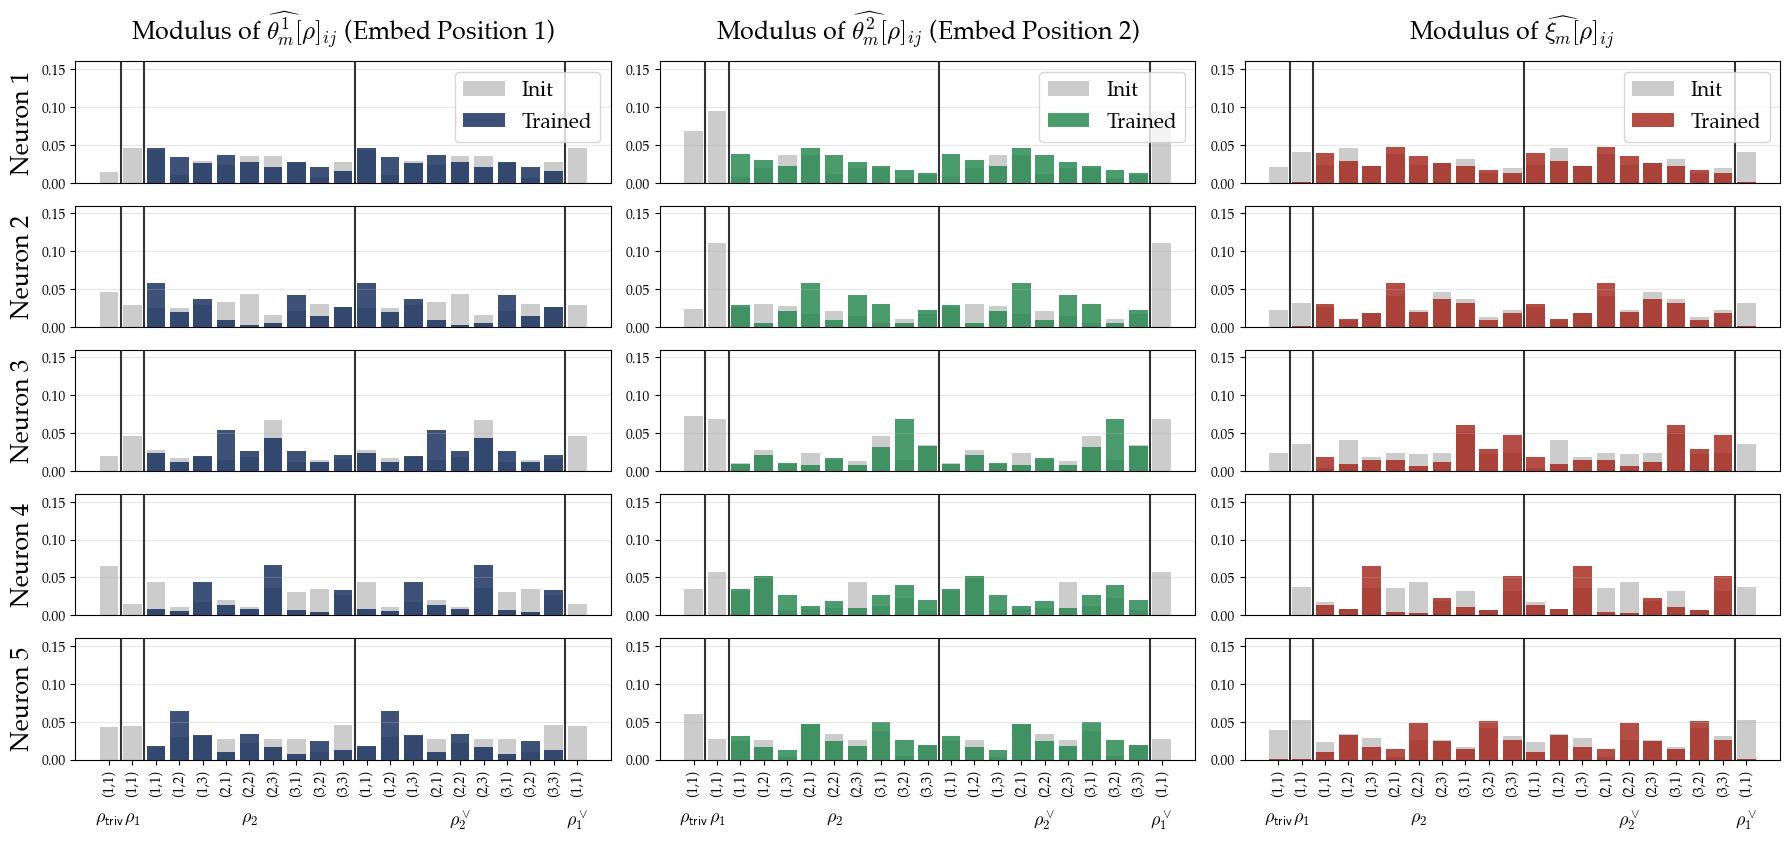

In [93]:
# Plot DFT magnitudes for first 5 neurons (bar plot)
freq_indices = np.arange(vocab_size)
num_neurons_to_show = 5

# Build basis labels (i,j) for each frequency (1-based indexing)
basis_labels = []
for label in basis.irrep_labels:
    d = basis.irrep_dimensions[label]
    for i in range(d):
        for j in range(d):
            basis_labels.append(f'({i+1},{j+1})')

# Compute center position for each irrep block
irrep_centers = []
for start, end in irrep_boundaries:
    center = (start + end - 1) / 2
    irrep_centers.append(center)

# Map irrep labels to LaTeX notation
irrep_latex_labels = {
    'trivial': r'$\rho_{\sf triv}$',
    'omega': r'$\rho_1$',
    'rho_3': r'$\rho_2$',
    'rho_3_conj': r'$\rho_2^\vee$',
    'omega_conj': r'$\rho_1^\vee$',
}

fig, axes = plt.subplots(num_neurons_to_show, 3, figsize=(18, 1.8 * num_neurons_to_show))

for row in range(num_neurons_to_show):
    m = row
    is_last_row = (row == num_neurons_to_show - 1)
    
    # Position 1 - Blue
    ax = axes[row, 0]
    ax.bar(freq_indices, W_in_init_pos1_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_in_pos1_mag[m], alpha=0.8, color='#0D2758', label='Trained')
    for start, end in irrep_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylabel(f'Neuron {m+1}', fontsize=18)
    ax.set_ylim(0, 0.16)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'Modulus of $\widehat{\theta_m^1}[\rho]_{ij}$ (Embed Position 1)', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=10, rotation=90)
        for i, (center, lbl) in enumerate(zip(irrep_centers, basis.irrep_labels)):
            ax.annotate(irrep_latex_labels[lbl], xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=13, fontweight='bold')
    else:
        ax.set_xticks([])
    
    # Position 2 - Green
    ax = axes[row, 1]
    ax.bar(freq_indices, W_in_init_pos2_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_in_pos2_mag[m], alpha=0.8, color='#1E8449', label='Trained')
    for start, end in irrep_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylim(0, 0.16)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'Modulus of $\widehat{\theta_m^2}[\rho]_{ij}$ (Embed Position 2)', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=10, rotation=90)
        for i, (center, lbl) in enumerate(zip(irrep_centers, basis.irrep_labels)):
            ax.annotate(irrep_latex_labels[lbl], xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=13, fontweight='bold')
    else:
        ax.set_xticks([])
    
    # Output - Red
    ax = axes[row, 2]
    ax.bar(freq_indices, W_out_init_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_out_mag[m], alpha=0.8, color='#A32015', label='Trained')
    for start, end in irrep_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylim(0, 0.16)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'Modulus of $\widehat{\xi_m}[\rho]_{ij}$', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=10, rotation=90)
        for i, (center, lbl) in enumerate(zip(irrep_centers, basis.irrep_labels)):
            ax.annotate(irrep_latex_labels[lbl], xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=13, fontweight='bold')
    else:
        ax.set_xticks([])

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

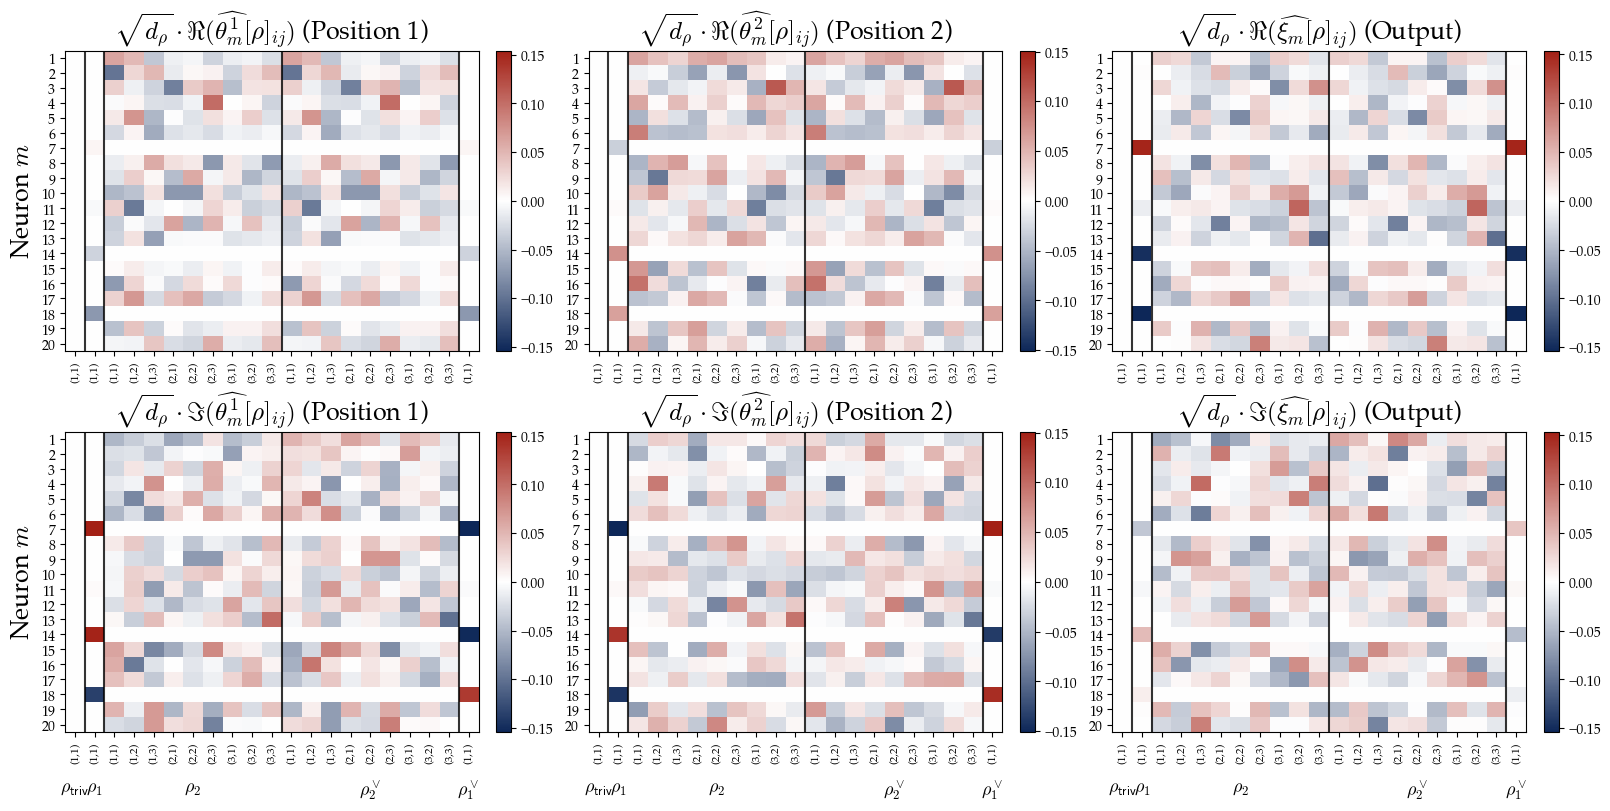

In [94]:
# Heatmap view: DFT coefficients for all neurons (2x3 grid)
# Top row: Real part, Bottom row: Imaginary part
# y-axis: neurons, x-axis: basis functions (frequencies)
# Plotting √d_ρ × ν̂[ρ] to show Plancherel-weighted coefficients

num_components = 20  # Number of neurons to show (adjustable)

# Build basis labels for x-axis
basis_labels_short = []
for label in basis.irrep_labels:
    d = basis.irrep_dimensions[label]
    for i in range(d):
        for j in range(d):
            basis_labels_short.append(f'({i+1},{j+1})')

x_locs = np.arange(vocab_size)
y_locs = np.arange(num_components)

# Scale DFT coefficients by √d_ρ for each irrep block
def scale_by_sqrt_d(dft_coeffs):
    """Scale each irrep block by √d_ρ."""
    scaled = dft_coeffs.clone()
    curr_idx = 0
    for label in basis.irrep_labels:
        d = basis.irrep_dimensions[label]
        block_size = d * d
        scaled[:, curr_idx:curr_idx + block_size] *= np.sqrt(d)
        curr_idx += block_size
    return scaled

# Apply √d_ρ scaling
W_in_pos1_dft_scaled = scale_by_sqrt_d(W_in_pos1_dft[:num_components])
W_in_pos2_dft_scaled = scale_by_sqrt_d(W_in_pos2_dft[:num_components])
W_out_dft_scaled = scale_by_sqrt_d(W_out_dft[:num_components])

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

# Get scaled DFT coefficients
data_pos1_re = W_in_pos1_dft_scaled.real.numpy()
data_pos1_im = W_in_pos1_dft_scaled.imag.numpy()
data_pos2_re = W_in_pos2_dft_scaled.real.numpy()
data_pos2_im = W_in_pos2_dft_scaled.imag.numpy()
data_out_re = W_out_dft_scaled.real.numpy()
data_out_im = W_out_dft_scaled.imag.numpy()

# Compute vmax for each column (shared between Re and Im)
vmax_pos1 = max(np.abs(data_pos1_re).max(), np.abs(data_pos1_im).max(), 0.1)
vmax_pos2 = max(np.abs(data_pos2_re).max(), np.abs(data_pos2_im).max(), 0.1)
vmax_out = max(np.abs(data_out_re).max(), np.abs(data_out_im).max(), 0.1)

titles = [
    [r'$\sqrt{d_\rho}\cdot\Re(\widehat{\theta_m^1}[\rho]_{ij})$ (Position 1)', r'$\sqrt{d_\rho}\cdot\Re(\widehat{\theta_m^2}[\rho]_{ij})$ (Position 2)', r'$\sqrt{d_\rho}\cdot\Re(\widehat{\xi_m}[\rho]_{ij})$ (Output)'],
    [r'$\sqrt{d_\rho}\cdot\Im(\widehat{\theta_m^1}[\rho]_{ij})$ (Position 1)', r'$\sqrt{d_\rho}\cdot\Im(\widehat{\theta_m^2}[\rho]_{ij})$ (Position 2)', r'$\sqrt{d_\rho}\cdot\Im(\widehat{\xi_m}[\rho]_{ij})$ (Output)'],
]
data_list = [
    [data_pos1_re, data_pos2_re, data_out_re],
    [data_pos1_im, data_pos2_im, data_out_im],
]
vmax_list = [vmax_pos1, vmax_pos2, vmax_out]

for row in range(2):
    for col in range(3):
        ax = axes[row, col]
        data = data_list[row][col]
        vmax = vmax_list[col]
        
        im = ax.imshow(data, cmap=blue_white_red, vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_title(titles[row][col], fontsize=18)
        
        # Y-axis label only on first column
        if col == 0:
            ax.set_ylabel('Neuron $m$', fontsize=18)
        
        ax.set_xticks(x_locs)
        ax.set_xticklabels(basis_labels_short, rotation=90, fontsize=8)
        ax.set_yticks(y_locs)
        ax.set_yticklabels(y_locs + 1)
        
        # Add irrep boundary lines
        for start, end in irrep_boundaries:
            if start > 0:
                ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
        
        # Add irrep labels at bottom (only on bottom row)
        if row == 1:
            for center, lbl in zip(irrep_centers, basis.irrep_labels):
                ax.annotate(irrep_latex_labels[lbl], xy=(center, -0.15), xycoords=('data', 'axes fraction'),
                           ha='center', va='top', fontsize=13, fontweight='bold')
        
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.savefig('../figures/frobenius21_dft_heatmap.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## 5. Fourier Coefficient Structure

We check if $\hat{\theta}^2_m[\rho] \cdot \hat{\theta}^1_m[\rho] \propto \hat{\xi}_m[\rho]$

**Notation:** All DFT coefficients use paper's L²(G) convention:
$$\hat{\nu}[\rho] = \frac{1}{|G|} \sum_{g \in G} \nu(g) \rho(g^{-1})$$
These are converted from the code's Euclidean coefficients via $\hat{\nu}[\rho] = C[\rho] / \sqrt{|G| \cdot d_\rho}$.

In [95]:
# Extract matrix-valued Fourier coefficients ν̂[ρ] for each irrep (paper notation)
def extract_irrep_matrices(dft_coeffs, irrep_labels, irrep_dims):
    """Extract d_ρ × d_ρ matrices from flattened DFT coefficients."""
    n_neurons = dft_coeffs.shape[0]
    irrep_matrices = {}
    
    curr_idx = 0
    for label in irrep_labels:
        d = irrep_dims[label]
        block = dft_coeffs[:, curr_idx:curr_idx + d*d]
        irrep_matrices[label] = block.reshape(n_neurons, d, d)
        curr_idx += d * d
    
    return irrep_matrices

# Extract matrices for each position and output (paper notation ν̂[ρ])
W_in_pos1_matrices = extract_irrep_matrices(W_in_pos1_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)
W_in_pos2_matrices = extract_irrep_matrices(W_in_pos2_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)
W_out_matrices = extract_irrep_matrices(W_out_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)

print("Extracted irrep matrices (paper notation ν̂[ρ]):")
for label, mat in W_in_pos1_matrices.items():
    d = basis.irrep_dimensions[label]
    print(f"  {label}: shape = {mat.shape} (neurons × {d} × {d})")

Extracted irrep matrices (paper notation ν̂[ρ]):
  trivial: shape = (128, 1, 1) (neurons × 1 × 1)
  omega: shape = (128, 1, 1) (neurons × 1 × 1)
  rho_3: shape = (128, 3, 3) (neurons × 3 × 3)
  rho_3_conj: shape = (128, 3, 3) (neurons × 3 × 3)
  omega_conj: shape = (128, 1, 1) (neurons × 1 × 1)


/var/folders/5n/bjfmhydx1099fm08r1bdw9br0000gn/T/ipykernel_12128/4049809301.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_plot = cm.get_cmap("plasma")


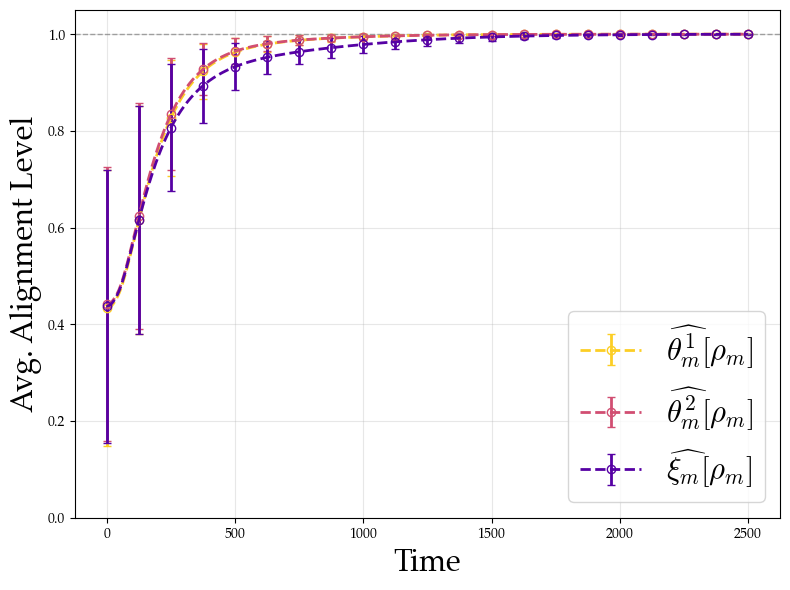

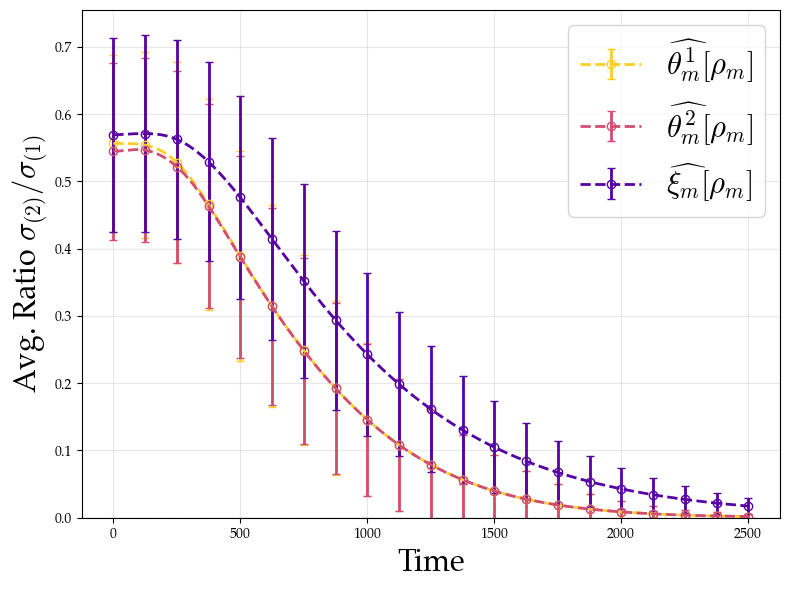

Final metrics at epoch 25000:
Alignment (mean +/- std):
  Cond 1: 0.9998 +/- 0.0005
  Cond 2: 1.0000 +/- 0.0000
  Cond 3: 1.0000 +/- 0.0000
Rank-1 ratio sigma2/sigma1 (d > 1 irreps):
  theta1: 0.001556 +/- 0.003459
  theta2: 0.001555 +/- 0.003456
  xi:     0.017152 +/- 0.012394
Non-trivial neurons: 128
Neurons with d > 1 irreps: 106


In [114]:
# Plot all metrics throughout training
# Uses alignment_history_all, grouped_energy_history_theta1/theta2/xi, rank1_history from cell-8

# === CONFIGURABLE: Set end epoch for plotting (None = plot all) ===
END_EPOCH = 25000  # e.g., 200, 500, or None for full training

# Convert to arrays
epochs_arr = np.array(epochs_tracked)
time_arr = epochs_arr * LR  # x-axis: epoch * lr
n_epochs = len(epochs_tracked)
n_neurons = grouped_energy_history_theta1[-1].shape[0]

# Filter to end epoch if specified
if END_EPOCH is not None:
    epoch_mask = epochs_arr <= END_EPOCH
    epochs_arr = epochs_arr[epoch_mask]
    time_arr = time_arr[epoch_mask]
    n_epochs = len(epochs_arr)

# Determine final dominant irrep (non-grouped) for alignment and rank-1 plots
final_energy_theta1 = grouped_energy_history_theta1[-1]
final_dominant_irreps = []
for m in range(n_neurons):
    dom_idx = np.argmax(final_energy_theta1[m])
    final_dominant_irreps.append(grouped_labels_cache[dom_idx])

# ============ COMPUTE ALIGNMENT METRICS ============
cond1_per_epoch, cond2_per_epoch, cond3_per_epoch = [], [], []
for t in range(n_epochs):
    c1_vals, c2_vals, c3_vals = [], [], []
    for m in range(n_neurons):
        dom_irrep = final_dominant_irreps[m]
        if dom_irrep == "trivial" or "+" in dom_irrep:
            if "+" in dom_irrep:
                dom_irrep = dom_irrep.split("+")[0]
        if dom_irrep == "trivial":
            continue
        if dom_irrep not in alignment_history_all:
            continue
        c1_vals.append(alignment_history_all[dom_irrep]["cond1"][t][m])
        c2_vals.append(alignment_history_all[dom_irrep]["cond2"][t][m])
        c3_vals.append(alignment_history_all[dom_irrep]["cond3"][t][m])
    cond1_per_epoch.append(c1_vals)
    cond2_per_epoch.append(c2_vals)
    cond3_per_epoch.append(c3_vals)

cond1_mean = np.array([np.mean(c) for c in cond1_per_epoch])
cond1_std = np.array([np.std(c) for c in cond1_per_epoch])
cond2_mean = np.array([np.mean(c) for c in cond2_per_epoch])
cond2_std = np.array([np.std(c) for c in cond2_per_epoch])
cond3_mean = np.array([np.mean(c) for c in cond3_per_epoch])
cond3_std = np.array([np.std(c) for c in cond3_per_epoch])

# ============ COMPUTE RANK-1 RATIO ============
theta1_sv_per_epoch, theta2_sv_per_epoch, xi_sv_per_epoch = [], [], []
for t in range(n_epochs):
    t1_vals, t2_vals, xi_vals = [], [], []
    for m in range(n_neurons):
        dom_irrep = final_dominant_irreps[m]
        if "+" in dom_irrep:
            dom_irrep = dom_irrep.split("+")[0]
        if dom_irrep == "trivial":
            continue
        if dom_irrep not in rank1_history:
            continue
        t1_vals.append(rank1_history[dom_irrep]["theta1"][t][m])
        t2_vals.append(rank1_history[dom_irrep]["theta2"][t][m])
        xi_vals.append(rank1_history[dom_irrep]["xi"][t][m])
    theta1_sv_per_epoch.append(t1_vals)
    theta2_sv_per_epoch.append(t2_vals)
    xi_sv_per_epoch.append(xi_vals)

theta1_sv_mean = np.array([np.mean(v) for v in theta1_sv_per_epoch])
theta1_sv_std = np.array([np.std(v) for v in theta1_sv_per_epoch])
theta2_sv_mean = np.array([np.mean(v) for v in theta2_sv_per_epoch])
theta2_sv_std = np.array([np.std(v) for v in theta2_sv_per_epoch])
xi_sv_mean = np.array([np.mean(v) for v in xi_sv_per_epoch])
xi_sv_std = np.array([np.std(v) for v in xi_sv_per_epoch])

# ============ SHARED COLOR SETUP (plasma colormap, 3 lines) ============
import matplotlib.cm as cm
cmap_plot = cm.get_cmap("plasma")
plot_colors = [cmap_plot(0.90 - 0.375 * i) for i in range(3)]  # purple -> teal -> yellow
err_every = max(1, len(time_arr) // 20)  # ~20 error bars across the x-axis
mark_every = max(1, len(time_arr) // 20)  # markers at same cadence

# ============ PLOT 1: Alignment metrics (order: cond2, cond3, cond1) ============
fig1, ax = plt.subplots(figsize=(8, 6))
plot1_data = [
    (cond2_mean, cond2_std,
     r'$\widehat{\theta^1_m}[\rho_m]$'),
    (cond3_mean, cond3_std,
     r'$\widehat{\theta^2_m}[\rho_m]$'),
    (cond1_mean, cond1_std,
     r'$\widehat{\xi_m}[\rho_m]$'),
]
for i, (mean, std, label) in enumerate(plot1_data):
    ax.errorbar(time_arr, mean, yerr=std, color=plot_colors[i], linewidth=2,
                linestyle="--", marker="o", markersize=6, markevery=mark_every, markerfacecolor="none",
                capsize=3, capthick=1, errorevery=err_every, label=label)
ax.set_xlabel(r"Time", fontsize=22)
ax.set_ylabel(r'Avg. Alignment Level', fontsize=22)
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(fontsize=22, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/frobenius21_alignment.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# ============ PLOT 3: Rank-1 ratio ============
fig3, ax = plt.subplots(figsize=(8, 6))
labels_sv = [
    r'$\widehat{\theta^1_m}[\rho_m]$',
    r'$\widehat{\theta^2_m}[\rho_m]$',
    r'$\widehat{\xi_m}[\rho_m]$',
]
for i, (mean, std) in enumerate([
    (theta1_sv_mean, theta1_sv_std),
    (theta2_sv_mean, theta2_sv_std),
    (xi_sv_mean, xi_sv_std)
]):
    ax.errorbar(time_arr, mean, yerr=std, color=plot_colors[i], linewidth=2,
                linestyle="--", marker="o", markersize=6, markevery=mark_every, markerfacecolor="none",
                capsize=3, capthick=1, errorevery=err_every, label=labels_sv[i])
ax.set_xlabel(r"Time", fontsize=22)
ax.set_ylabel(r'Avg. Ratio $\sigma_{(2)} / \sigma_{(1)}$', fontsize=22)
ax.set_ylim(0, None)
ax.axhline(y=0.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(fontsize=22, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/frobenius21_rank1.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final metrics at epoch {epochs_arr[-1]}:")
print(f"Alignment (mean +/- std):")
print(f"  Cond 1: {cond1_mean[-1]:.4f} +/- {cond1_std[-1]:.4f}")
print(f"  Cond 2: {cond2_mean[-1]:.4f} +/- {cond2_std[-1]:.4f}")
print(f"  Cond 3: {cond3_mean[-1]:.4f} +/- {cond3_std[-1]:.4f}")
print(f"Rank-1 ratio sigma2/sigma1 (d > 1 irreps):")
print(f"  theta1: {theta1_sv_mean[-1]:.6f} +/- {theta1_sv_std[-1]:.6f}")
print(f"  theta2: {theta2_sv_mean[-1]:.6f} +/- {theta2_sv_std[-1]:.6f}")
print(f"  xi:     {xi_sv_mean[-1]:.6f} +/- {xi_sv_std[-1]:.6f}")
print(f"Non-trivial neurons: {len(cond1_per_epoch[0])}")
print(f"Neurons with d > 1 irreps: {len(theta1_sv_per_epoch[0]) if theta1_sv_per_epoch else 0}")


In [97]:
# Verify that Fourier coefficients are genuinely complex (not purely real)
# For conjugate irrep pairs, coefficients should be complex conjugates

# Use relative threshold: E_ρ / Σ_ρ E_ρ > threshold (energy fraction in dominant irrep)
ENERGY_FRACTION_THRESHOLD = 0.90

print("Verifying Fourier coefficients are complex (|Im|/|total| ratio)")
print("=" * 85)
print(f"{'Irrep (grouped)':<25} {'# Neurons':<12} {'W1 Im ratio':<15} {'W2 Im ratio':<15} {'Complex?':<12}")
print("-" * 85)

for gi, glabel in enumerate(grouped_labels):
    # Compute energy fraction in this irrep pair
    total_energy = np.sum(energy_pos1_grouped, axis=1)
    energy_fraction = energy_pos1_grouped[:, gi] / (total_energy + 1e-10)
    specialized = np.where(energy_fraction > ENERGY_FRACTION_THRESHOLD)[0]
    
    if len(specialized) == 0:
        print(f"{glabel:<25} {'0':<12} {'N/A':<15} {'N/A':<15} {'(skipped)':<12}")
        continue
    
    if '+' in glabel:
        # Conjugate pair - use one of them (they have same magnitude)
        parts = glabel.split('+')
        label = parts[0]
        W1_mats = W_in_pos1_matrices[label][specialized]
        W2_mats = W_in_pos2_matrices[label][specialized]
    else:
        label = glabel
        W1_mats = W_in_pos1_matrices[label][specialized]
        W2_mats = W_in_pos2_matrices[label][specialized]
    
    # Compute mean imaginary ratio across specialized neurons
    im_ratios_w1 = []
    im_ratios_w2 = []
    for m in range(len(specialized)):
        im_ratios_w1.append(np.linalg.norm(W1_mats[m].imag, 'fro') / (np.linalg.norm(W1_mats[m], 'fro') + 1e-10))
        im_ratios_w2.append(np.linalg.norm(W2_mats[m].imag, 'fro') / (np.linalg.norm(W2_mats[m], 'fro') + 1e-10))
    
    mean_im_w1 = np.mean(im_ratios_w1)
    mean_im_w2 = np.mean(im_ratios_w2)
    is_complex = "YES" if (mean_im_w1 > 0.1 or mean_im_w2 > 0.1) else "NO (real)"
    
    print(f"{glabel:<25} {len(specialized):<12} {mean_im_w1:<15.4f} {mean_im_w2:<15.4f} {is_complex:<12}")

print("-" * 85)

# For conjugate pairs, verify that coefficients are indeed conjugates
print("\nConjugate pair verification (coefficients should be conjugates):")
for glabel in grouped_labels:
    if '+' not in glabel:
        continue
    parts = glabel.split('+')
    label1, label2 = parts[0], parts[1]
    
    total_energy = np.sum(energy_pos1_grouped, axis=1)
    energy_fraction = energy_pos1_grouped[:, grouped_labels.index(glabel)] / (total_energy + 1e-10)
    specialized = np.where(energy_fraction > ENERGY_FRACTION_THRESHOLD)[0]
    
    if len(specialized) == 0:
        continue
    
    # Check if W[ρ] ≈ conj(W[ρ̄])
    conj_errors = []
    for m in specialized[:10]:  # Check first 10
        w1_rho = W_in_pos1_matrices[label1][m]
        w1_rho_bar = W_in_pos1_matrices[label2][m]
        conj_errors.append(np.linalg.norm(w1_rho - w1_rho_bar.conj(), 'fro'))
    
    mean_err = np.mean(conj_errors)
    print(f"  {glabel}: Mean ||ν̂[ρ] - ν̂[ρ̄]*||_F = {mean_err:.2e} {'✓' if mean_err < 1e-10 else '✗'}")

Verifying Fourier coefficients are complex (|Im|/|total| ratio)
Irrep (grouped)           # Neurons    W1 Im ratio     W2 Im ratio     Complex?    
-------------------------------------------------------------------------------------
trivial                   0            N/A             N/A             (skipped)   
omega+omega_conj          22           0.8137          0.8236          YES         
rho_3+rho_3_conj          106          0.6992          0.6889          YES         
-------------------------------------------------------------------------------------

Conjugate pair verification (coefficients should be conjugates):
  omega+omega_conj: Mean ||ν̂[ρ] - ν̂[ρ̄]*||_F = 1.58e-17 ✓
  rho_3+rho_3_conj: Mean ||ν̂[ρ] - ν̂[ρ̄]*||_F = 0.00e+00 ✓


Selected neurons and their dominant irreps:
  Neuron 1: rho_3 (dim=3)
  Neuron 3: rho_3 (dim=3)
  Neuron 4: rho_3 (dim=3)


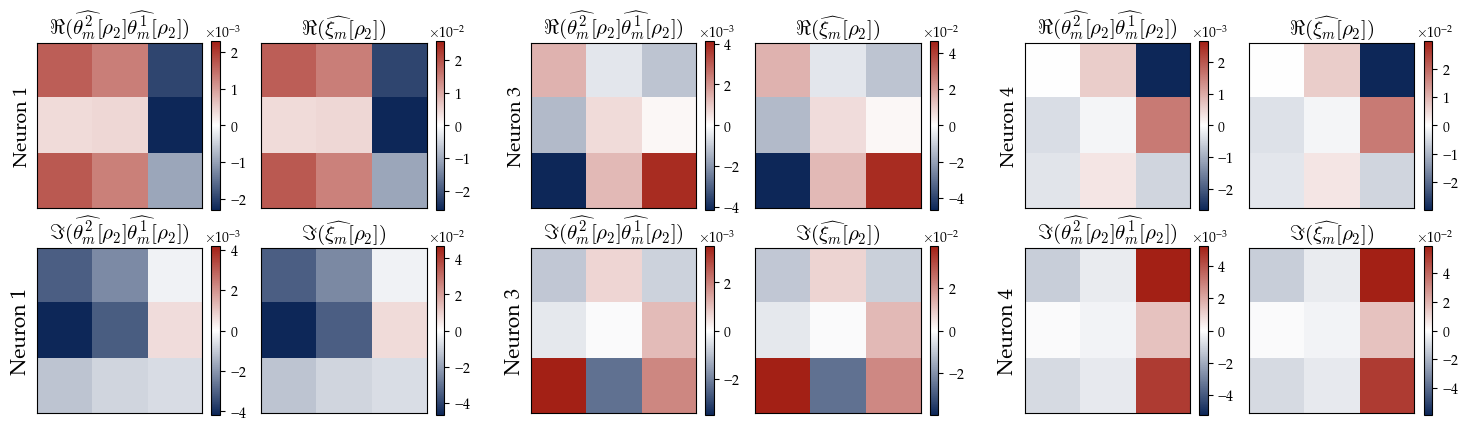


Proportionality check: W2 @ W1 ≈ c · Wout
Neuron     Irrep           Residual        Status         
------------------------------------------------------------
1          rho_3           0.0036          ✓ Aligned      
3          rho_3           0.0077          ✓ Aligned      
4          rho_3           0.0068          ✓ Aligned      


In [98]:
# Compare W2 @ W1 vs Wout for selected neurons
# 2×6 grid: Top row = Real, Bottom row = Imaginary
# Columns alternate: neuron1 product, neuron1 xi, neuron2 product, neuron2 xi, ...
# Automatically detects which irrep each neuron specializes in

from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

# ============ USER CONFIGURATION ============
# Select neurons by their IDs (0-indexed)
selected_neuron_ids = [0,2,3]  # Just pick any 3 neurons
# ============================================

# LaTeX labels for irreps
irrep_latex = {
    'trivial': r'\rho_{\sf triv}',
    'omega': r'\rho_1',
    'rho_3': r'\rho_2',
    'rho_3_conj': r'\rho_2^\vee',
    'omega_conj': r'\rho_1^\vee',
}

def get_dominant_irrep(neuron_idx):
    """Find which irrep a neuron specializes in (highest energy)."""
    energies = energy_pos1[neuron_idx]
    dominant_idx = np.argmax(energies)
    return basis.irrep_labels[dominant_idx]

def add_colorbar_scientific(fig, im, ax):
    """Add colorbar with scientific notation (10^{-n} scale), offset text moved right."""
    cbar = fig.colorbar(im, ax=ax, fraction=0.046)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.ticklabel_format(style='scientific', scilimits=(-2, 2))
    # Move the exponent label (×10^n) to the right
    cbar.ax.yaxis.get_offset_text().set_x(3.5)
    return cbar

# Detect irrep for each selected neuron
neuron_irreps = [(m, get_dominant_irrep(m)) for m in selected_neuron_ids]
print("Selected neurons and their dominant irreps:")
for m, irrep in neuron_irreps:
    d = basis.irrep_dimensions[irrep]
    print(f"  Neuron {m+1}: {irrep} (dim={d})")

# Create figure with GridSpec for custom spacing
# 8 columns: [n1_prod, n1_xi, gap, n2_prod, n2_xi, gap, n3_prod, n3_xi]
fig = plt.figure(figsize=(18, 5))
gs = GridSpec(2, 8, figure=fig,
              width_ratios=[1, 1, 0.02, 1, 1, 0.02, 1, 1],
              hspace=0.14, wspace=0.3)

# Map neuron index to actual grid columns (skipping gap columns)
col_map = [(0, 1), (3, 4), (6, 7)]  # (product_col, xi_col) for each neuron

for i, (m, irrep_label) in enumerate(neuron_irreps):
    d = basis.irrep_dimensions[irrep_label]
    rho_tex = irrep_latex.get(irrep_label, irrep_label)

    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]

    # W2 @ W1 (paper's convention)
    W2_W1 = W2 @ W1

    col_product, col_xi = col_map[i]

    # Top row: Real parts
    # W2@W1 Real - independent colorbar
    ax = fig.add_subplot(gs[0, col_product])
    vmax_w2w1_re = max(np.abs(W2_W1.real).max(), 1e-10)
    im = ax.imshow(W2_W1.real, cmap=blue_white_red, vmin=-vmax_w2w1_re, vmax=vmax_w2w1_re)
    ax.set_title(r'$\Re(\widehat{\theta_m^2}[' + rho_tex + r']\widehat{\theta_m^1}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'Neuron {m+1}', fontsize=14)
    add_colorbar_scientific(fig, im, ax)

    # Wout Real - independent colorbar
    ax = fig.add_subplot(gs[0, col_xi])
    vmax_wout_re = max(np.abs(Wout.real).max(), 1e-10)
    im = ax.imshow(Wout.real, cmap=blue_white_red, vmin=-vmax_wout_re, vmax=vmax_wout_re)
    ax.set_title(r'$\Re(\widehat{\xi_m}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    add_colorbar_scientific(fig, im, ax)

    # Bottom row: Imaginary parts
    # W2@W1 Imag - independent colorbar
    ax = fig.add_subplot(gs[1, col_product])
    vmax_w2w1_im = max(np.abs(W2_W1.imag).max(), 1e-10)
    im = ax.imshow(W2_W1.imag, cmap=blue_white_red, vmin=-vmax_w2w1_im, vmax=vmax_w2w1_im)
    ax.set_title(r'$\Im(\widehat{\theta_m^2}[' + rho_tex + r']\widehat{\theta_m^1}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'Neuron {m+1}', fontsize=15)
    add_colorbar_scientific(fig, im, ax)

    # Wout Imag - independent colorbar
    ax = fig.add_subplot(gs[1, col_xi])
    vmax_wout_im = max(np.abs(Wout.imag).max(), 1e-10)
    im = ax.imshow(Wout.imag, cmap=blue_white_red, vmin=-vmax_wout_im, vmax=vmax_wout_im)
    ax.set_title(r'$\Im(\widehat{\xi_m}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    add_colorbar_scientific(fig, im, ax)

plt.savefig('../figures/frobenius21_fourier_product.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\nProportionality check: W2 @ W1 ≈ c · Wout")
print("=" * 60)
print(f"{'Neuron':<10} {'Irrep':<15} {'Residual':<15} {'Status':<15}")
print("-" * 60)
for m, irrep_label in neuron_irreps:
    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]

    W2_W1 = W2 @ W1
    W2_W1_norm = W2_W1 / (np.linalg.norm(W2_W1, 'fro') + 1e-10)
    Wout_norm = Wout / (np.linalg.norm(Wout, 'fro') + 1e-10)
    residual = np.linalg.norm(W2_W1_norm - Wout_norm, 'fro')
    status = "✓ Aligned" if residual < 0.1 else "✗ Misaligned"

    print(f"{m+1:<10} {irrep_label:<15} {residual:<15.4f} {status:<15}")

In [99]:
# Check if θ̂₁, θ̂₂, ξ̂ matrices are rank-1 for ALL neurons
# A rank-1 matrix M can be written as M = u @ v^H (outer product)
# We check this by looking at singular values: σ₁ >> σ₂ ≈ ... ≈ σ_d ≈ 0
#
# Note: Singular values (from SVD) are ALWAYS real and non-negative, even for complex matrices.
#       Eigenvalues can be complex. For rank-1 check, we use singular values.

RANK1_THRESHOLD = 0.1  # σ₂/σ₁ < threshold means rank-1

# Collect statistics for all neurons
rank1_stats = {'θ̂₁': {'rank1': 0, 'total': 0, 'ratios': []},
               'θ̂₂': {'rank1': 0, 'total': 0, 'ratios': []},
               'ξ̂': {'rank1': 0, 'total': 0, 'ratios': []}}

all_neuron_data = []  # Store data for all neurons

for m in range(M):
    # Find dominant irrep for this neuron
    energies = energy_pos1[m]
    dom_idx = np.argmax(energies)
    irrep_label = basis.irrep_labels[dom_idx]
    d = basis.irrep_dimensions[irrep_label]
    
    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]
    
    neuron_info = {'m': m, 'irrep': irrep_label, 'd': d}
    
    for name, mat in [('θ̂₁', W1), ('θ̂₂', W2), ('ξ̂', Wout)]:
        singular_values = np.linalg.svd(mat, compute_uv=False)
        sigma1 = singular_values[0]
        sigma2 = singular_values[1] if len(singular_values) > 1 else 0
        ratio = sigma2 / sigma1 if sigma1 > 1e-10 else np.inf
        
        neuron_info[f'{name}_σ1'] = sigma1
        neuron_info[f'{name}_σ2'] = sigma2
        neuron_info[f'{name}_ratio'] = ratio
        neuron_info[f'{name}_rank1'] = ratio < RANK1_THRESHOLD
        
        # Also compute eigenvalues (can be complex)
        eigenvalues = np.linalg.eigvals(mat)
        neuron_info[f'{name}_eigs'] = eigenvalues
        
        # Only count d > 1 for statistics
        if d > 1:
            rank1_stats[name]['total'] += 1
            rank1_stats[name]['ratios'].append(ratio)
            if ratio < RANK1_THRESHOLD:
                rank1_stats[name]['rank1'] += 1
    
    all_neuron_data.append(neuron_info)

# Summary statistics
print("Rank-1 check for Fourier coefficient matrices (ALL neurons)")
print("=" * 80)
print("\nNote: We use SINGULAR VALUES (always real ≥ 0) for rank check, not eigenvalues.")
print("      Eigenvalues of complex matrices can be complex.")
print(f"\nSummary (d > 1 irreps only, threshold σ₂/σ₁ < {RANK1_THRESHOLD}):")
print("-" * 80)
print(f"{'Matrix':<10} {'Rank-1':<12} {'Total':<12} {'Percentage':<12} {'Mean σ₂/σ₁':<15} {'Max σ₂/σ₁':<15}")
print("-" * 80)
for name, stats in rank1_stats.items():
    pct = 100 * stats['rank1'] / stats['total'] if stats['total'] > 0 else 0
    mean_ratio = np.mean(stats['ratios']) if stats['ratios'] else 0
    max_ratio = np.max(stats['ratios']) if stats['ratios'] else 0
    print(f"{name:<10} {stats['rank1']:<12} {stats['total']:<12} {pct:<12.1f}% {mean_ratio:<15.6f} {max_ratio:<15.6f}")

# Count by irrep type
print("\n" + "=" * 80)
print("Breakdown by irrep type:")
print("-" * 80)

for irrep_label in basis.irrep_labels:
    d = basis.irrep_dimensions[irrep_label]
    if d == 1:
        count = sum(1 for n in all_neuron_data if n['irrep'] == irrep_label)
        print(f"{irrep_label} (d=1): {count} neurons - trivially rank-1")
    else:
        neurons_in_irrep = [n for n in all_neuron_data if n['irrep'] == irrep_label]
        count = len(neurons_in_irrep)
        if count > 0:
            rank1_theta1 = sum(1 for n in neurons_in_irrep if n['θ̂₁_rank1'])
            rank1_theta2 = sum(1 for n in neurons_in_irrep if n['θ̂₂_rank1'])
            rank1_xi = sum(1 for n in neurons_in_irrep if n['ξ̂_rank1'])
            print(f"{irrep_label} (d={d}): {count} neurons")
            print(f"    θ̂₁ rank-1: {rank1_theta1}/{count} ({100*rank1_theta1/count:.1f}%)")
            print(f"    θ̂₂ rank-1: {rank1_theta2}/{count} ({100*rank1_theta2/count:.1f}%)")
            print(f"    ξ̂  rank-1: {rank1_xi}/{count} ({100*rank1_xi/count:.1f}%)")

# Show first 10 neurons with d > 1 irreps in detail (with both singular values and eigenvalues)
print("\n" + "=" * 120)
print("Detailed view (first 10 neurons with d > 1 irreps):")
print("Showing both SINGULAR VALUES (real) and EIGENVALUES (complex)")
print("=" * 120)

count_shown = 0
for n in all_neuron_data:
    if n['d'] == 1:
        continue
    if count_shown >= 10:
        break
    
    print(f"\nNeuron {n['m']+1} ({n['irrep']}, d={n['d']}):")
    print("-" * 100)
    
    for name in ['θ̂₁', 'θ̂₂', 'ξ̂']:
        status = "✓ Rank-1" if n[f'{name}_rank1'] else "✗ Full rank"
        
        # Format singular values
        sv_str = f"σ = [{n[f'{name}_σ1']:.6f}, {n[f'{name}_σ2']:.6f}, ...]"
        
        # Format eigenvalues (complex)
        eigs = n[f'{name}_eigs']
        eig_strs = [f"{e.real:.4f}{'+' if e.imag >= 0 else ''}{e.imag:.4f}j" for e in eigs[:3]]
        eig_str = f"λ = [{', '.join(eig_strs)}]"
        
        print(f"  {name}: {status}")
        print(f"       Singular values (real): {sv_str}  (σ₂/σ₁ = {n[f'{name}_ratio']:.6f})")
        print(f"       Eigenvalues (complex):  {eig_str}")
    
    count_shown += 1

print(f"\n(Showing {count_shown} of {sum(1 for n in all_neuron_data if n['d'] > 1)} neurons with d > 1 irreps)")

Rank-1 check for Fourier coefficient matrices (ALL neurons)

Note: We use SINGULAR VALUES (always real ≥ 0) for rank check, not eigenvalues.
      Eigenvalues of complex matrices can be complex.

Summary (d > 1 irreps only, threshold σ₂/σ₁ < 0.1):
--------------------------------------------------------------------------------
Matrix     Rank-1       Total        Percentage   Mean σ₂/σ₁      Max σ₂/σ₁      
--------------------------------------------------------------------------------
θ̂₁        106          106          100.0       % 0.000279        0.005873       
θ̂₂        106          106          100.0       % 0.000279        0.005851       
ξ̂         106          106          100.0       % 0.006873        0.041094       

Breakdown by irrep type:
--------------------------------------------------------------------------------
trivial (d=1): 0 neurons - trivially rank-1
omega (d=1): 14 neurons - trivially rank-1
rho_3 (d=3): 106 neurons
    θ̂₁ rank-1: 106/106 (100.0%)
    θ̂₂

In [100]:
# Compute Ω_m = Σ_{ρ≠1} d_ρ · tr(ξ̂_m[ρ]^H θ̂²_m[ρ] θ̂¹_m[ρ]) for each neuron
# 
# The DFT coefficients are already in paper's L²(G) notation:
#   ν̂[ρ] = (1/|G|) Σ_g ν(g) ρ(g⁻¹)
# So we can directly apply the paper formula.

def compute_omega_m(m):
    """Compute Ω_m for neuron m using paper's DFT coefficients."""
    omega_m = 0.0
    for label in basis.irrep_labels:
        if label == 'trivial':
            continue
        d = basis.irrep_dimensions[label]
        
        # Paper's L²(G) DFT coefficients ν̂[ρ]
        xi_hat = W_out_matrices[label][m]
        theta2_hat = W_in_pos2_matrices[label][m]
        theta1_hat = W_in_pos1_matrices[label][m]
        
        # Paper formula: d_ρ · tr(ξ̂^H @ θ̂² @ θ̂¹)
        product = xi_hat.conj().T @ theta2_hat @ theta1_hat
        omega_m += d * np.trace(product)
    
    return omega_m.real

# Print table
print("Ω_m = Σ_{ρ≠1} d_ρ · tr(ξ̂_m[ρ]^H θ̂²_m[ρ] θ̂¹_m[ρ])")
print("(using paper's L²(G) DFT coefficients)")
print("=" * 40)
print(f"{'Neuron':<10} {'Ω_m':<15}")
print("-" * 40)
for m in range(min(20, M)):  # Show first 20 neurons
    omega_m = compute_omega_m(m)
    print(f"{m+1:<10} {omega_m:<15.6f}")
print("-" * 40)

Ω_m = Σ_{ρ≠1} d_ρ · tr(ξ̂_m[ρ]^H θ̂²_m[ρ] θ̂¹_m[ρ])
(using paper's L²(G) DFT coefficients)
Neuron     Ω_m            
----------------------------------------
1          0.004242       
2          0.004242       
3          0.004242       
4          0.004242       
5          0.004242       
6          0.004242       
7          0.007348       
8          0.004242       
9          0.004242       
10         0.004242       
11         0.004223       
12         0.004242       
13         0.004242       
14         0.007348       
15         0.004242       
16         0.004242       
17         0.004242       
18         0.007348       
19         0.004242       
20         0.004242       
----------------------------------------


In [101]:
# Verify the loss formula:
# 
# R_ap(Θ) = |G|² log|G| - (2a|G|²/M) Σ_m Ω_m
#
# where a = init_scale³ and Ω_m = Σ_{ρ≠1} d_ρ · tr(θ̂²_m[ρ] θ̂¹_m[ρ] ξ̂_m[ρ]*)
#
# This is a key theoretical result connecting the cross-entropy loss
# to the Fourier-domain structure of the weights.

# Compute sum of all Ω_m
omega_sum = sum(compute_omega_m(m) for m in range(M))

# Parameters
G = G_ORDER  # |G| = 21
a = INIT_SCALE ** 3  # a = init_scale³ = 0.5³ = 0.125

# Theoretical prediction: |G|² log|G| - (2a|G|²/M) Σ_m Ω_m
baseline = G**2 * np.log(G)
omega_contribution = (2 * a * G**2 / M) * omega_sum
theoretical_loss = baseline - omega_contribution

# Actual loss from training
actual_loss = losses[-1]

print("=" * 70)
print("Loss Formula Verification: R_ap = |G|² log|G| - (2a|G|²/M) Σ_m Ω_m")
print("=" * 70)
print(f"\nParameters:")
print(f"  |G| = {G}")
print(f"  M (width) = {M}")
print(f"  init_scale = {INIT_SCALE}")
print(f"  a = init_scale³ = {INIT_SCALE}³ = {a}")

print(f"\nComponents:")
print(f"  |G|² log|G| = {G}² × log({G}) = {G**2} × {np.log(G):.6f} = {baseline:.6f}")
print(f"  Σ_m Ω_m = {omega_sum:.6f}")
print(f"  (2a|G|²/M) = 2 × {a} × {G**2} / {M} = {2 * a * G**2 / M:.6f}")
print(f"  (2a|G|²/M) × Σ_m Ω_m = {omega_contribution:.6f}")

print(f"\nTheoretical Loss = |G|² log|G| - (2a|G|²/M) Σ_m Ω_m")
print(f"                 = {baseline:.6f} - {omega_contribution:.6f}")
print(f"                 = {theoretical_loss:.6f}")

print(f"\nActual Loss (from training) = {actual_loss:.6f}")

print(f"\nComparison:")
print(f"  Difference = {abs(theoretical_loss - actual_loss):.6f}")
print(f"  Relative Error = {abs(theoretical_loss - actual_loss) / actual_loss * 100:.4f}%")

if abs(theoretical_loss - actual_loss) / actual_loss < 0.01:
    print("\n✓ Loss formula verified! (< 1% relative error)")
else:
    print("\n✗ Loss formula does not match (> 1% relative error)")
print("=" * 70)

Loss Formula Verification: R_ap = |G|² log|G| - (2a|G|²/M) Σ_m Ω_m

Parameters:
  |G| = 21
  M (width) = 128
  init_scale = 0.5
  a = init_scale³ = 0.5³ = 0.125

Components:
  |G|² log|G| = 21² × log(21) = 441 × 3.044522 = 1342.634395
  Σ_m Ω_m = 0.611279
  (2a|G|²/M) = 2 × 0.125 × 441 / 128 = 0.861328
  (2a|G|²/M) × Σ_m Ω_m = 0.526512

Theoretical Loss = |G|² log|G| - (2a|G|²/M) Σ_m Ω_m
                 = 1342.634395 - 0.526512
                 = 1342.107883

Actual Loss (from training) = 1342.371094

Comparison:
  Difference = 0.263211
  Relative Error = 0.0196%

✓ Loss formula verified! (< 1% relative error)


## 6. Representation Distribution Analysis

Which irreducible representations do neurons specialize to?

In [102]:
# Count which irrep each neuron specializes to (using grouped irreps)

irrep_counts_raw = {label: 0 for label in basis.irrep_labels}
irrep_counts_grouped = {glabel: 0 for glabel in grouped_labels}

for m in range(M):
    # Raw count (individual irreps)
    dom_freq = basis.get_dominant_frequency(W_in_pos1_dft[m])
    curr_idx = 0
    for label in basis.irrep_labels:
        dim = basis.irrep_dimensions[label]
        if dom_freq < curr_idx + dim * dim:
            irrep_counts_raw[label] += 1
            break
        curr_idx += dim * dim
    
    # Grouped count
    dom_grouped_idx = np.argmax(energy_pos1_grouped[m])
    irrep_counts_grouped[grouped_labels[dom_grouped_idx]] += 1

print("Neuron specialization by irreducible representation:")
print("=" * 70)
print("\nRaw counts (individual irreps):")
for label, count in irrep_counts_raw.items():
    dim = basis.irrep_dimensions[label]
    print(f"  {label} (dim={dim}): {count} neurons ({100*count/M:.1f}%)")

print("\nGrouped counts (conjugate pairs combined):")
for glabel, count in irrep_counts_grouped.items():
    if '+' in glabel:
        parts = glabel.split('+')
        d1 = basis.irrep_dimensions[parts[0]]
        dim_str = f"{d1}+{d1}"
    else:
        dim_str = str(basis.irrep_dimensions[glabel])
    print(f"  {glabel} (dim={dim_str}): {count} neurons ({100*count/M:.1f}%)")

print("\n" + "=" * 70)
print("Note: Frobenius21 has TWO pairs of conjugate irreps:")
print("  - omega & omega_conj (1D)")
print("  - rho_3 & rho_3_conj (3D)")
print("Their Fourier coefficients are complex conjugates of each other.")
print("Neurons specializing to these pairs contribute to a real-valued output.")

Neuron specialization by irreducible representation:

Raw counts (individual irreps):
  trivial (dim=1): 0 neurons (0.0%)
  omega (dim=1): 14 neurons (10.9%)
  rho_3 (dim=3): 106 neurons (82.8%)
  rho_3_conj (dim=3): 0 neurons (0.0%)
  omega_conj (dim=1): 8 neurons (6.2%)

Grouped counts (conjugate pairs combined):
  trivial (dim=1): 0 neurons (0.0%)
  omega+omega_conj (dim=1+1): 22 neurons (17.2%)
  rho_3+rho_3_conj (dim=3+3): 106 neurons (82.8%)

Note: Frobenius21 has TWO pairs of conjugate irreps:
  - omega & omega_conj (1D)
  - rho_3 & rho_3_conj (3D)
Their Fourier coefficients are complex conjugates of each other.
Neurons specializing to these pairs contribute to a real-valued output.
